### 1. Introduction

This notebook performs an initial exploratory analysis of the Retailrocket e-commerce dataset. The objective is to understand the structure, quality and characteristics of the data prior to preprocessing, session construction and feature engineering. Exploratory data analysis is undertaken to identify data quality issues, understand user interaction patterns and inform the design of the Bayesian Network developed later in this project.

### 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

### 3. Load Datasets

Four datasets are provided within the Retailrocket dataset:

- events.csv
- category_tree.csv
- item_properties_part1.csv
- item_properties_part2.csv

These datasets contain user interactions, product hierarchy and product metadata.

In [2]:
events = pd.read_csv("../data/raw/events.csv")
category_tree = pd.read_csv("../data/raw/category_tree.csv")
item_properties_part1 = pd.read_csv("../data/raw/item_properties_part1.csv")
item_properties_part2 = pd.read_csv("../data/raw/item_properties_part2.csv")

In [3]:
dataset_summary = pd.DataFrame({
    "Dataset": ["Events",
                "Category Tree",
                "Item Properties Part 1",
                "Item Properties Part 2"],
    "Rows": [
        events.shape[0],
        category_tree.shape[0],
        item_properties_part1.shape[0],
        item_properties_part2.shape[0]
    ],
    "Columns": [
        events.shape[1],
        category_tree.shape[1],
        item_properties_part1.shape[1],
        item_properties_part2.shape[1]
    ]
})

dataset_summary

,Dataset,Rows,Columns
0,Events,2756101,5
1,Category Tree,1669,2
2,Item Properties Part 1,10999999,4
3,Item Properties Part 2,9275903,4


### 4. Initial Data Exploration

This section provides an initial overview of the Retailrocket dataset to understand its structure and content before data preprocessing. The analysis examines the dimensions, variables, data types and summary statistics of each dataset to identify their purpose and assess their suitability for subsequent session construction and Bayesian Network modelling. This initial inspection also provides an understanding of the information available within the user interaction, product hierarchy and item property datasets.

#### 4.1 Events Dataset

In [4]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [5]:
events.info()
events.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


,timestamp,visitorid,event,itemid,transactionid
count,2.756101e+06,2.756101e+06,2756101,2.756101e+06,22457.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,view,NaN,NaN
freq,NaN,NaN,2664312,NaN,NaN
mean,1.436424e+12,7.019229e+05,NaN,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,NaN,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,NaN,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,NaN,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,NaN,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,NaN,3.507150e+05,13224.000000


#### 4.2 Category Dataset

In [6]:
category_tree.head()

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [7]:
category_tree.info()
category_tree.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


,categoryid,parentid
count,1669.000000,1644.000000
mean,849.285201,847.571168
std,490.195116,505.058485
min,0.000000,8.000000
25%,427.000000,381.000000
50%,848.000000,866.000000
75%,1273.000000,1291.000000
max,1698.000000,1698.000000


#### 4.3 Item Properties Part 1 Dataset

In [8]:
item_properties_part1.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [9]:
item_properties_part1.info()
item_properties_part1.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999999 entries, 0 to 10999998
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 335.7+ MB


,timestamp,itemid,property,value
count,1.100000e+07,1.100000e+07,10999999,10999999
unique,NaN,NaN,1097,1231581
top,NaN,NaN,888,769062
freq,NaN,NaN,1629817,833710
mean,1.435158e+12,2.333851e+05,NaN,NaN
std,3.327653e+09,1.348258e+05,NaN,NaN
min,1.431227e+12,0.000000e+00,NaN,NaN
25%,1.432436e+12,1.165150e+05,NaN,NaN
50%,1.433646e+12,2.334990e+05,NaN,NaN
75%,1.437880e+12,3.501860e+05,NaN,NaN


#### 4.4 Item Properties Part 2 Dataset

In [10]:
item_properties_part2.head()

,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525
3,1431831600000,403324,917,1204143
4,1435460400000,230701,521,769062


In [11]:
item_properties_part2.info()
item_properties_part2.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9275903 entries, 0 to 9275902
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 283.1+ MB


,timestamp,itemid,property,value
count,9.275903e+06,9.275903e+06,9275903,9275903
unique,NaN,NaN,1094,1075730
top,NaN,NaN,888,769062
freq,NaN,NaN,1370581,703537
mean,1.435156e+12,2.333968e+05,NaN,NaN
std,3.327970e+09,1.348682e+05,NaN,NaN
min,1.431227e+12,0.000000e+00,NaN,NaN
25%,1.432436e+12,1.165175e+05,NaN,NaN
50%,1.433646e+12,2.334620e+05,NaN,NaN
75%,1.437880e+12,3.504470e+05,NaN,NaN


### 5. Data Quality Assessment


This section evaluates the quality of the Retailrocket dataset by examining missing values, duplicate records and data types. Assessing data quality prior to preprocessing is essential to ensure the reliability of subsequent analyses and identify any issues requiring cleaning or transformation before session construction and feature engineering.

#### 5.1 Missing Values

Missing values were examined across all four datasets to identify incomplete records that may require preprocessing before analysis.

In [12]:
print("Events")
display(events.isnull().sum())

print("Category Tree")
display(category_tree.isnull().sum())

print("Item Properties Part 1")
display(item_properties_part1.isnull().sum())

print("Item Properties Part 2")
display(item_properties_part2.isnull().sum())

Events


timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

Category Tree


categoryid     0
parentid      25
dtype: int64

Item Properties Part 1


timestamp    0
itemid       0
property     0
value        0
dtype: int64

Item Properties Part 2


timestamp    0
itemid       0
property     0
value        0
dtype: int64

The events dataset contains missing values only within the `transactionid` variable. This is expected, as transaction IDs are recorded only for purchase events, while view and add-to-cart events do not result in a transaction. The category tree dataset contains 25 missing parent category IDs, representing root categories within the hierarchy. No missing values were identified in either of the item properties datasets.

#### 5.2 Duplicate Records

Duplicate records were identified to determine whether repeated observations were present within the datasets.

In [13]:
print("Events:", events.duplicated().sum())
print("Category Tree:", category_tree.duplicated().sum())
print("Item Properties Part 1:", item_properties_part1.duplicated().sum())
print("Item Properties Part 2:", item_properties_part2.duplicated().sum())

Events: 460
Category Tree: 0
Item Properties Part 1: 0
Item Properties Part 2: 0


A total of 460 duplicate records were identified within the events dataset, while no duplicate records were found in the remaining datasets. These duplicates will be investigated further during preprocessing to determine whether they represent genuine repeated user interactions or redundant records that should be removed.

#### 5.3 Data Types

The data types of each variable were reviewed to ensure that they were appropriate for analysis and to identify any variables requiring conversion.

In [14]:
events.dtypes

timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object

In [15]:
category_tree.dtypes

categoryid      int64
parentid      float64
dtype: object

In [16]:
item_properties_part1.dtypes

timestamp     int64
itemid        int64
property     object
value        object
dtype: object

In [17]:
item_properties_part2.dtypes

timestamp     int64
itemid        int64
property     object
value        object
dtype: object

The data types are generally appropriate for analysis. Numeric identifiers are stored as integer values, while categorical variables such as event type and item properties are stored as objects. Timestamp variables were initially stored as Unix timestamps measured in milliseconds and therefore required conversion to datetime format before temporal analysis and session construction.

#### 5.4 Timestamp Conversion

The timestamp variables are stored as Unix timestamps measured in milliseconds. These values were converted to datetime format to support temporal analysis and session construction.

In [18]:
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms")
item_properties_part1["timestamp"] = pd.to_datetime(item_properties_part1["timestamp"], unit="ms")
item_properties_part2["timestamp"] = pd.to_datetime(item_properties_part2["timestamp"], unit="ms")

In [19]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,2015-06-02 05:02:12.117,257597,view,355908,NaN
1,2015-06-02 05:50:14.164,992329,view,248676,NaN
2,2015-06-02 05:13:19.827,111016,view,318965,NaN
3,2015-06-02 05:12:35.914,483717,view,253185,NaN
4,2015-06-02 05:02:17.106,951259,view,367447,NaN


#### 5.5 Summary of Data Quality

Overall, the Retailrocket dataset is of high quality, with relatively few data quality issues identified. Missing values are limited to variables where they are expected based on the dataset structure, and duplicate records are confined to a small proportion of the events dataset. Following timestamp conversion, the datasets are suitable for preprocessing, exploratory data analysis and subsequent session-based modelling.

### 6. Exploratory Data Analysis

This section explores the characteristics of the Retailrocket dataset to understand user behaviour, event distributions, product interactions and temporal activity patterns. The findings provide context for the dataset and inform the preprocessing, session construction and feature engineering stages of the project.

#### 6.1 Distribution of Event Types

The distribution of event types was analysed to understand the composition of user interactions recorded within the dataset. Examining the relative frequency of views, add-to-cart events and transactions provides an indication of user behaviour and highlights any class imbalance that may influence model development and evaluation.

In [20]:
# Count each event type
event_counts = events["event"].value_counts()

# Calculate percentages
event_percentages = events["event"].value_counts(normalize=True) * 100

# Create summary table
event_summary = pd.DataFrame({
    "Count": event_counts,
    "Percentage (%)": event_percentages.round(2)
})

display(event_summary)

,Count,Percentage (%)
event,,
view,2664312,96.67
addtocart,69332,2.52
transaction,22457,0.81


The event distribution is highly imbalanced, with views accounting for 96.67% of all recorded interactions, compared with 2.52% for add-to-cart events and 0.81% for transactions. This indicates that purchase-related behaviour is relatively rare within the raw event data. Although the final prediction target is constructed at session level rather than event level, this initial imbalance informed the later choice to evaluate predictive models using precision, recall, F1-score and PR-AUC alongside accuracy.

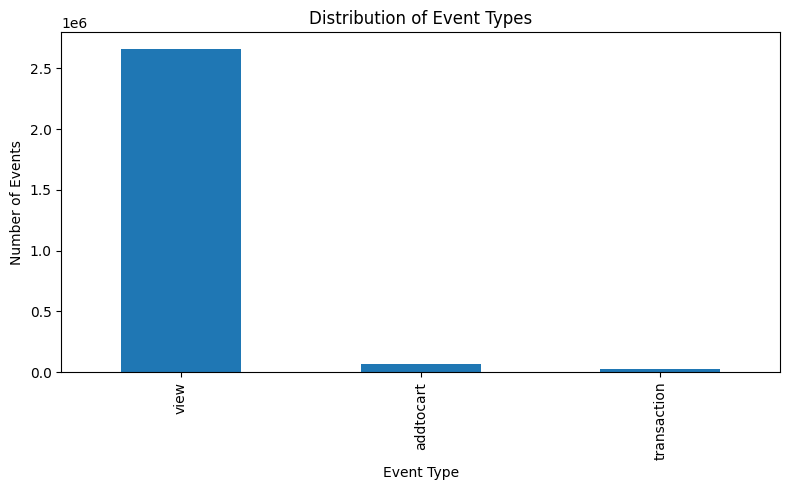

In [21]:
# Plot event distribution
ax = event_counts.plot(
    kind="bar",
    figsize=(8,5)
)

ax.set_title("Distribution of Event Types")
ax.set_xlabel("Event Type")
ax.set_ylabel("Number of Events")

plt.tight_layout()
plt.show()

#### 6.2 Visitor Statistics

Visitor statistics were calculated to understand the scale of user activity represented within the dataset. Examining the number of unique visitors and the distribution of events per visitor provides insight into browsing behaviour and user engagement.

In [22]:
# Number of unique visitors
unique_visitors = events["visitorid"].nunique()

# Number of events per visitor
events_per_visitor = events.groupby("visitorid").size()

visitor_summary = pd.DataFrame({
    "Statistic": [
        "Unique Visitors",
        "Mean Events per Visitor",
        "Median Events per Visitor",
        "Maximum Events by a Visitor"
    ],
    "Value": [
        unique_visitors,
        round(events_per_visitor.mean(),2),
        events_per_visitor.median(),
        events_per_visitor.max()
    ]
})

display(visitor_summary)

,Statistic,Value
0,Unique Visitors,1407580.00
1,Mean Events per Visitor,1.96
2,Median Events per Visitor,1.00
3,Maximum Events by a Visitor,7757.00


Visitor activity was highly uneven. Although the dataset contained 1,407,580 unique visitors, the median visitor generated only one recorded event, compared with a mean of 1.96 events and a maximum of 7,757 events for a single visitor. This indicates a strongly right-skewed distribution in which most visitors interacted only briefly while a small number generated substantially more activity. This variation further supports constructing session-level observations, allowing related interactions from the same browsing journey to be represented together rather than treating individual events as independent observations.

#### 6.3 Item Statistics

Item statistics were examined to understand the diversity of products represented within the dataset and identify the items receiving the greatest levels of user interaction.

In [23]:
# Number of unique items
unique_items = events["itemid"].nunique()

print(f"Unique Items: {unique_items:,}")

Unique Items: 235,061


Item activity was also highly uneven, with 235,061 unique items represented in the event data. The median item appeared in only three recorded events, while a small number of items appeared substantially more frequently. Modelling individual item identifiers would therefore introduce a very high-cardinality feature with many sparsely observed categories. Instead, later session-level modelling summarised browsing breadth using the number of unique items interacted with during each session, providing a more compact and interpretable behavioural feature.`

In [24]:
# Top 10 most interacted items
top_items = events["itemid"].value_counts().head(10)

display(top_items)

itemid
187946    3412
461686    2978
5411      2334
370653    1854
219512    1800
257040    1647
298009    1642
96924     1633
309778    1628
384302    1608
Name: count, dtype: int64

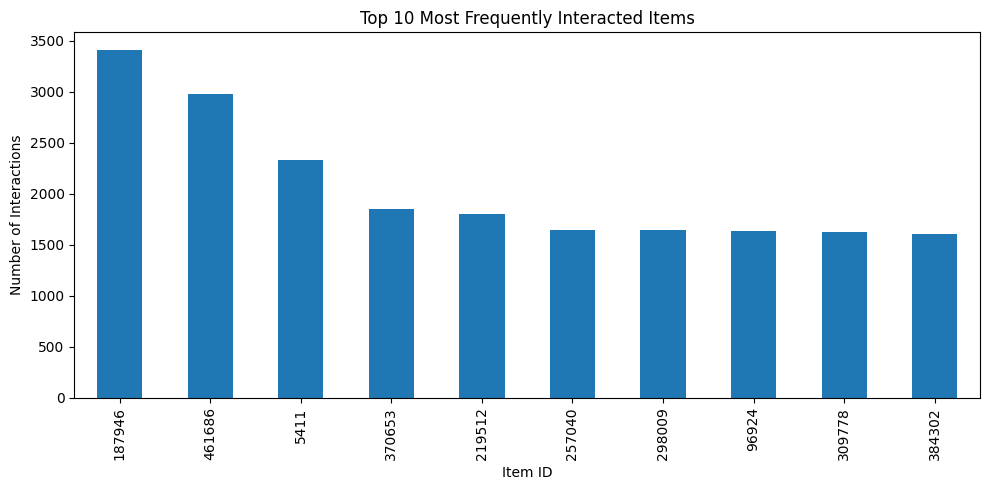

In [25]:
ax = top_items.plot(
    kind="bar",
    figsize=(10,5)
)

ax.set_title("Top 10 Most Frequently Interacted Items")
ax.set_xlabel("Item ID")
ax.set_ylabel("Number of Interactions")

plt.tight_layout()
plt.show()

#### 6.4 Temporal Coverage

The temporal coverage of the dataset was examined to determine the period over which user interactions were collected and to understand the duration of the observation window.

In [26]:
print("Start Date:", events["timestamp"].min())
print("End Date:", events["timestamp"].max())
print("Observation Period:", events["timestamp"].max() - events["timestamp"].min())

Start Date: 2015-05-03 03:00:04.384000
End Date: 2015-09-18 02:59:47.788000
Observation Period: 137 days 23:59:43.404000


The temporal analysis showed that interaction activity varied across both the time of day and day of the week, indicating that browsing behaviour was not uniformly distributed over time. These patterns motivated retaining temporal information during feature engineering. Rather than using the raw timestamp directly, later modelling represented temporal behaviour through *time_of_day* and *day_of_week*, providing interpretable categorical features that could be incorporated into both logistic regression and the Bayesian Network.

#### 6.5 Daily Activity

Daily event volumes were analysed to identify temporal patterns in user activity and determine whether interaction levels remained consistent throughout the observation period.

In [27]:
events["date"] = events["timestamp"].dt.date

daily_events = events.groupby("date").size()

display(daily_events.head())

date
2015-05-03    13683
2015-05-04    19414
2015-05-05    23015
2015-05-06    23920
2015-05-07    23164
dtype: int64

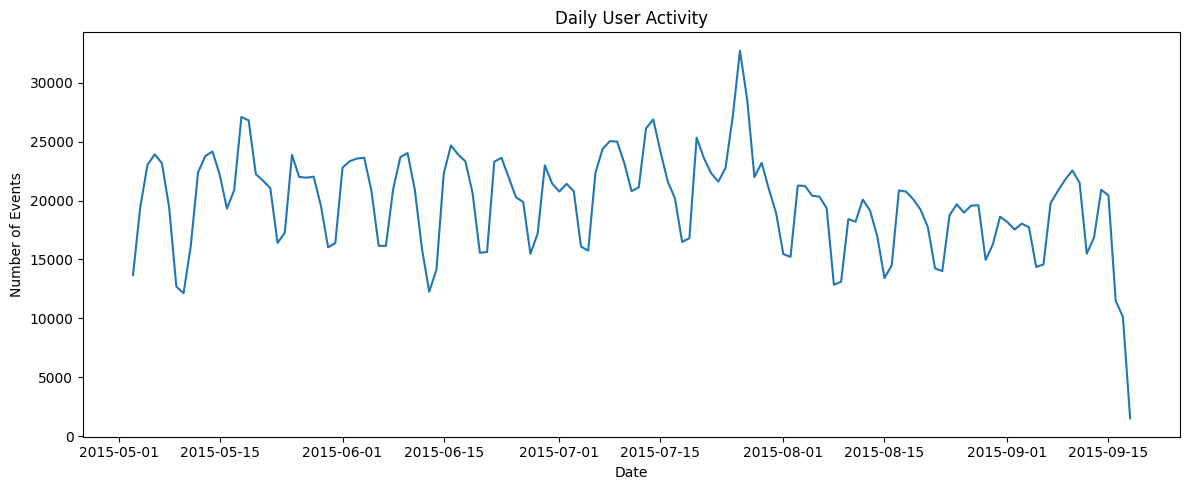

In [28]:
ax = daily_events.plot(
    figsize=(12,5)
)

ax.set_title("Daily User Activity")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Events")

plt.tight_layout()
plt.show()

#### 6.6 Event Type Trends Over Time

Daily activity was further examined by separating interactions according to event type, allowing trends in browsing, add-to-cart behaviour and completed transactions to be compared over time.

In [29]:
daily_event_types = (
    events
    .groupby(["date", "event"])
    .size()
    .unstack(fill_value=0)
)

display(daily_event_types.head())

event,addtocart,transaction,view
date,,,
2015-05-03,296,83,13304
2015-05-04,579,154,18681
2015-05-05,565,225,22225
2015-05-06,647,258,23015
2015-05-07,578,217,22369


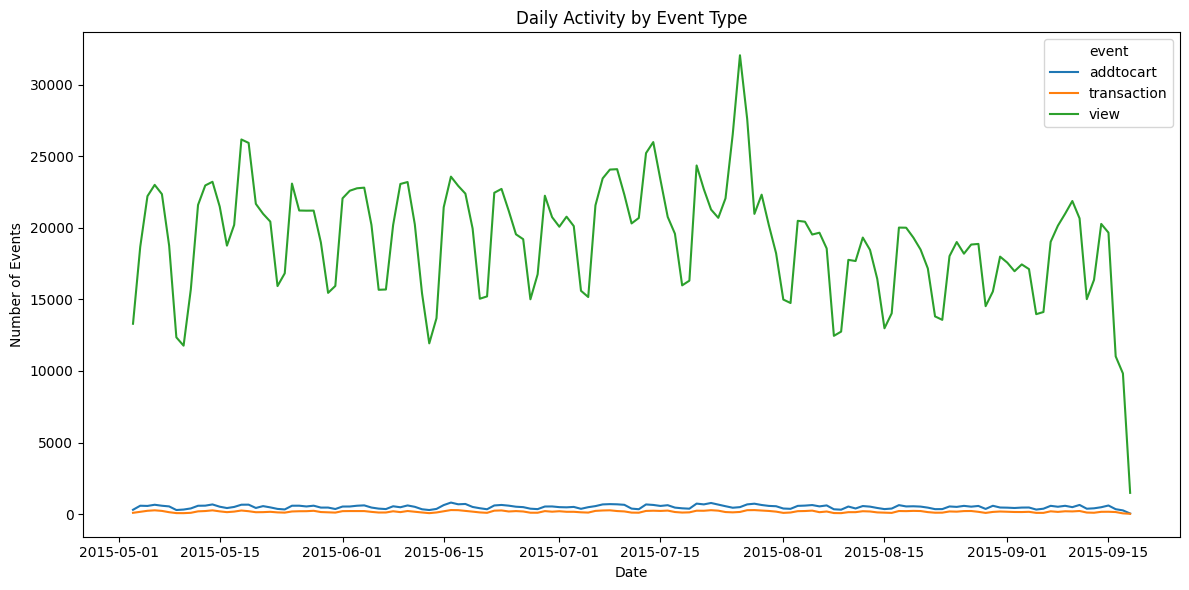

In [30]:
ax = daily_event_types.plot(
    figsize=(12,6)
)

ax.set_title("Daily Activity by Event Type")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Events")

plt.tight_layout()
plt.show()

#### 6.7 Transaction Analysis

Transaction activity was examined in greater detail because conversion represents the primary outcome of interest in this study. Understanding the frequency and distribution of transactions provides an initial indication of the degree of class imbalance that may need to be addressed during session-level modelling.

In [31]:
# Isolate transaction events
transactions = events[events["event"] == "transaction"]

# Basic transaction statistics
print(f"Transaction events: {len(transactions):,}")
print(f"Unique transactions: {transactions['transactionid'].nunique():,}")
print(f"Visitors making a transaction: {transactions['visitorid'].nunique():,}")

transaction_percentage = (len(transactions) / len(events)) * 100
print(f"Transactions as percentage of all events: {transaction_percentage:.2f}%")

Transaction events: 22,457
Unique transactions: 17,672
Visitors making a transaction: 11,719
Transactions as percentage of all events: 0.81%


The dataset contains 22,457 transaction events representing 17,672 unique transactions, with 11,719 visitors completing at least one transaction. Transaction events account for only 0.81% of all recorded interactions, indicating that purchasing behaviour is substantially less frequent than non-transaction activity. This provides initial evidence of considerable class imbalance within the dataset. However, the final degree of imbalance relevant to the prediction task will be assessed after individual events have been grouped into sessions and a session-level conversion target has been constructed.

#### 6.8 Summary of Exploratory Analysis

The exploratory analysis demonstrates that the Retailrocket dataset contains a large volume of behavioural data covering product views, add-to-cart events and transactions. User interactions are strongly dominated by product views, while transaction events account for only 0.81% of all recorded interactions. A total of 22,457 transaction events were identified, corresponding to 17,672 unique transactions and 11,719 visitors who completed at least one transaction.

The analysis also identified substantial variation in the level of activity across visitors and items, alongside temporal variation in user interactions throughout the observation period. These characteristics provide important context for the subsequent modelling process.

The low frequency of transaction events provides initial evidence of class imbalance, although the class distribution relevant to the prediction task cannot be determined until individual events have been grouped into sessions. The next stage of the project will therefore focus on preprocessing and session construction, after which session-level behavioural features and a binary conversion outcome can be derived for modelling.

### Next Steps

The next stage of the analysis will be conducted in `02_preprocessing_session_construction.ipynb` and will include:

- preprocessing of the event data;
- construction of visitor sessions using an inactivity threshold;
- examination of the resulting session distribution;
- creation of a session-level conversion target;
- development of behavioural features for subsequent modelling.